# Training with pytorch
> Training model with pytorch

In [ ]:
#| default_exp patching.training_pytorch

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#| export
import sys
from pathlib import Path
from fastcore.all import *
from fastcore.script import *
import monai

In [ ]:
#| export
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch
import socket


In [ ]:
#| export
CV_TOOLS = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/cv_tools')
front = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/private_front_easy_pin_detection')
current_lib = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/new_test')
sys.path.append(str(CV_TOOLS))
sys.path.append(str(front))
sys.path.append(str(current_lib))


In [ ]:
#| export
custom_lib_path = Path(r'/home/ai_warstein/homes/goni/custom_libs')
sys.path.append(str(custom_lib_path))
sys.path.append(str())

In [ ]:
#| export
from cv_tools.imports import *
from cv_tools.core import *
from dotenv import load_dotenv


In [ ]:
#| export
load_dotenv(dotenv_path=f'/home/ai_sintercra/homes/hasan/projects/git_data/new_test/new_test/.env')

False

In [ ]:
#|exporti
from new_test.patching.model_development import *


In [ ]:
#| export
from private_front_easy_pin_detection.dataloader_creation import *
from private_front_easy_pin_detection.training_pipeline import *

In [ ]:
HOST_NAME = socket.gethostname()

In [ ]:
model_ = ModelForTraining(
    in_channels=1,
    out_channels=1,
    with_clahe=True,
    with_denoise=True,
    with_bias_field_correction=True
)
if system() == 'Windows':
    trn_im_path = Path(r'E:\CurrentTrainingData20240812_trn_val\training_zero_degree_solder_pin/train/patch300_images')
elif system() == 'Linux' and HOST_NAME == '127.0.0.1':
    trn_im_path = Path(r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/curated_images')
else:
    trn_im_path = Path(r'/home/ai_easypid.work/CurrentTrainingData20240812_trn_val/training_zero_degree_solder_pin/train/patch300_images')
trn_msk_path = Path(Path(trn_im_path).parent, 'curated_masks')
val_im_path = Path(Path(trn_im_path).parent, 'patch256_val_images')
val_msk_path = Path(Path(val_im_path).parent, 'patch256_val_masks')
print(val_im_path)
print(f'Training image path: {trn_im_path} and mask path: {trn_msk_path}')
print(f'Validation image path: {val_im_path} and mask path: {val_msk_path}')
val_im_path.exists(), val_msk_path.exists()


/home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch256_val_images
Training image path: /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/curated_images and mask path: /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/curated_masks
Validation image path: /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch256_val_images and mask path: /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch256_val_masks


(True, True)

In [ ]:
paths = [trn_im_path, trn_msk_path, val_im_path, val_msk_path]
for i in paths:
    print(i.exists())

True
True
True
True


In [ ]:
#| export

# Custom Dataset class
class PinSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = Path(image_dir).ls()
        self.masks = Path(mask_dir).ls()
        self.transform = transform

        super().__init__()
        store_attr()
    __repr__ = basic_repr()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        name = Path(img_path).name
        mask_path = Path(self.mask_dir, name)
        image = Image.open(img_path).convert('L')
        mask = Image.open(mask_path).convert('L')


        if self.transform:
            # Apply same transform to both image and mask using same random state
            seed = torch.randint(0, 2**32, (1,)).item()
            torch.manual_seed(seed)
            image = self.transform(image)
            torch.manual_seed(seed)
            mask = self.transform(mask)
        else:
            # Convert to tensors if no transform
            image = torch.from_numpy(image, dtype=torch.float32).unsqueeze(0)  # Add channel dimension
            mask = torch.from_numpy(mask, dtype=torch.float32).unsqueeze(0)    # Add channel dimension

        # Ensure mask is binary
        mask = torch.where(mask > 0.5, 1.0, 0.0)

        return image, mask


In [ ]:
#| export
from torchvision import transforms as T

In [ ]:
#| export
def get_training_augmentation(
    IMAGE_HEIGHT: int = 256,
    IMAGE_WIDTH: int = 256,

):
    from torchvision import transforms as T
    
    train_transform = T.Compose([
        T.RandomResizedCrop(size=(IMAGE_HEIGHT, IMAGE_WIDTH), scale=(0.8, 1.0), ratio=(0.75, 1.33)),
        #T.RandomPerspective(distortion_scale=0.3, p=0.3),
        T.RandomHorizontalFlip(p=0.4),
        T.RandomVerticalFlip(p=0.4),
        T.RandomRotation(degrees=5),
        #T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        #T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        T.ToTensor(),
    ])
    return train_transform


In [ ]:
#| export
def get_validation_augmentation(
    IMAGE_HEIGHT: int = 256,
    IMAGE_WIDTH: int = 256,

):
    val_transform = T.Compose([
        T.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
        T.ToTensor(),
    ])
    return val_transform

In [ ]:
#| export
def get_dataloader(
    trn_im_path:str, 
    trn_msk_path:str,
    val_im_path:str,
    val_msk_path:str,
    tst_im_path:str=None,
    batch_size:int = 32,
    IMAGE_HEIGHT:int=256,
    IMAGE_WIDTH:int=256,
    num_workers:int=4   
    ):
    'Create datalaoder'
    trn_transform = get_training_augmentation(
        IMAGE_HEIGHT=IMAGE_HEIGHT,
        IMAGE_WIDTH=IMAGE_WIDTH,
    )
    val_transform = get_validation_augmentation(
        IMAGE_HEIGHT=IMAGE_HEIGHT,
        IMAGE_WIDTH=IMAGE_WIDTH,
    )
    if val_im_path is None:
        trn_ds = PinSegmentationDataset(
            image_dir=trn_im_path, 
            mask_dir=trn_msk_path,
            transform=trn_transform)
        trn_ds, val_ds = split_ds(trn_ds, val_split=0.2)
        # changing the trnsforms in case of validation and training datasets
        trn_ds.dataset.transform = trn_transform
        val_ds.dataset.transform = val_transform
    else:
        trn_ds = PinSegmentationDataset(
            image_dir=trn_im_path, 
            mask_dir=trn_msk_path,
            transform=trn_transform)
        val_ds = PinSegmentationDataset(
            image_dir=val_im_path, 
            mask_dir=val_msk_path,
            transform=val_transform)

    trn_dataloader = DataLoader(
        trn_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers
    )
    val_dataloader = DataLoader(
        val_ds, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers
    )
    if tst_im_path:
        tst_ds = InferenceDataset(tst_im_path, transform=val_transform)
        tst_dl = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        return trn_dataloader, val_dataloader, tst_dl
    else:
        return trn_dataloader, val_dataloader


In [ ]:
batch_size = 16
num_workers = 1
trn_dl, val_dl = get_dataloader(
    trn_im_path=Path(trn_im_path),
    trn_msk_path=Path(trn_msk_path),
    val_im_path=Path(val_im_path),
    val_msk_path=Path(val_msk_path),
    batch_size=batch_size,
    num_workers=num_workers
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


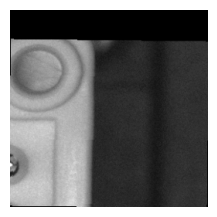

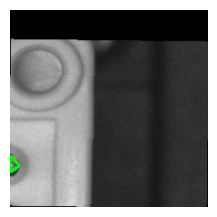

In [ ]:
imgs, msks = next(iter(trn_dl))
imgs.shape, msks.shape
show_(imgs[0][0,:])
#show_(msks[0][0,:])
show_(overlay_mask_border_on_image_frm_img(np.array(imgs[0][0,:]), np.array(msks[0][0,:])))

In [ ]:
imgs[0].min(),imgs[0].max(), msks[0].unique()


(tensor(0.), tensor(1.), tensor([0., 1.]))

In [ ]:
imgs[0].unique()

tensor([0.0000, 0.0039, 0.0078, 0.0118, 0.0157, 0.0196, 0.0235, 0.0275, 0.0314,
        0.0353, 0.0392, 0.0431, 0.0471, 0.0510, 0.0549, 0.0588, 0.0627, 0.0667,
        0.0706, 0.0745, 0.0784, 0.0824, 0.0863, 0.0902, 0.0941, 0.0980, 0.1020,
        0.1059, 0.1098, 0.1137, 0.1176, 0.1216, 0.1255, 0.1294, 0.1333, 0.1373,
        0.1412, 0.1451, 0.1490, 0.1529, 0.1569, 0.1608, 0.1647, 0.1686, 0.1725,
        0.1765, 0.1804, 0.1843, 0.1882, 0.1922, 0.1961, 0.2000, 0.2039, 0.2078,
        0.2118, 0.2157, 0.2196, 0.2235, 0.2275, 0.2314, 0.2353, 0.2392, 0.2431,
        0.2471, 0.2510, 0.2549, 0.2588, 0.2627, 0.2667, 0.2706, 0.2745, 0.2784,
        0.2824, 0.2863, 0.2902, 0.2941, 0.2980, 0.3020, 0.3059, 0.3098, 0.3137,
        0.3176, 0.3216, 0.3255, 0.3294, 0.3333, 0.3373, 0.3412, 0.3451, 0.3490,
        0.3529, 0.3569, 0.3608, 0.3647, 0.3686, 0.3725, 0.3765, 0.3804, 0.3843,
        0.3882, 0.3922, 0.3961, 0.4000, 0.4039, 0.4078, 0.4118, 0.4157, 0.4196,
        0.4235, 0.4275, 0.4314, 0.4353, 

In [ ]:
#| export
def get_end_test_model(
	in_channels:int=1,
	out_channels:int=1,
	training:bool=True,
	with_clahe:bool=True,
	with_denoise:bool=True,
	with_bias_field_correction:bool=True
	):
	if training:
		model = ModelForTraining(
			in_channels=in_channels,
			out_channels=out_channels,
			with_clahe=with_clahe,
			with_denoise=with_denoise,
			with_bias_field_correction=with_bias_field_correction
		)
	else:
		model = ModelForInference(
			in_channels=in_channels,
			out_channels=out_channels,
			with_clahe=with_clahe,
			with_denoise=with_denoise,
			with_bias_field_correction=with_bias_field_correction)
	return model
	

In [ ]:
model = get_end_test_model(
    in_channels=1,
    out_channels=1,
    training=True,
    with_clahe=True,
    with_denoise=True,
    with_bias_field_correction=True)
x = torch.randn(1, 1, 256, 256)
y = model(x)
y.shape

torch.Size([1, 1, 256, 256])

In [ ]:
model_inf = get_end_test_model(
    in_channels=1,
	out_channels=1,
	training=False
)

In [ ]:
#idx = np.random.choice(len(trn_dataset), 1)[0]
#img, mask = trn_dataset[idx]
#img_np = img.numpy()
#msk_np = mask.numpy()
#im_n = np.transpose(img_np, (1, 2, 0)).squeeze()
#msk_n = np.transpose(msk_np, (1, 2, 0)).squeeze()
#show_(im_n), show_(msk_n)

In [ ]:
#| export
CURRETNT_NB='/home/ai_sintercra/homes/hasan/projects/git_data/new_test/nbs'

In [ ]:
#| export
@call_parse
def main_(
		trn_im_path:Param(type=str, help='Training image path')='',
		trn_msk_path:Param(type=str, help='Training mask path')='',
		val_im_path:Param(type=str, help='Validation image path')='',
		val_msk_path:Param(type=str, help='Validation mask path')='',
		batch_size:Param(type=int, help='Batch size') = 16,
		num_workers:Param(type=int, help='Number of workers') = 1,
		in_channels:Param(type=int, help='Number of input channels') = 1,
		out_channels:Param(type=int, help='Number of output channels') = 1,
		#training:Param(type=bool, help='Training') = True,
		#with_clahe:Param(type=bool, help='With CLAHE') = False,
		#with_denoise:Param(type=bool, help='With denoise') = True,
		#with_bias_field_correction:Param(type=bool, help='With bias field correction') = True,
		lr:Param(type=float, help='Learning rate') = 0.001,
		num_epochs:Param(type=int, help='Number of epochs') = 10,
		device:Param(type=str, help='Device') = 'cuda' if torch.cuda.is_available() else 'cpu',
		threshold:Param(type=float, help='Threshold') = 0.5,
		save_path:Param(type=str, help='Save path') = None,
		model_fn:Param(type=str, help='Model function') = None
):
	#model = get_end_test_model(
		#in_channels=in_channels,
		#out_channels=out_channels,
		#training=training,
		#with_clahe=with_clahe,
		#with_denoise=with_denoise,
		#with_bias_field_correction=with_bias_field_correction)
	model = get_end_test_only_model(
		in_channels=in_channels,
		out_channels=out_channels,
	)

	# Creating dataloaders
	trn_dl, val_dl = get_dataloader(
		trn_im_path=Path(trn_im_path),
		trn_msk_path=Path(trn_msk_path),
		val_im_path=Path(val_im_path),
		val_msk_path=Path(val_msk_path),
		batch_size=batch_size,
		num_workers=num_workers)
	
	# Creating optimizer
	optimizer = torch.optim.Adam(
		model.parameters(), lr=lr)
	metrics = [
		calculate_foreground_iou]
	scheduler = CosineAnnealingLR(
		optimizer,
		T_max=num_epochs,
		eta_min=0.0001)

	loss_fn = monai.losses.FocalLoss(
		include_background=True, 
		gamma=2,
		alpha=0.25,
		use_softmax=False)


	train_and_validate(
		model=model,
		num_epochs=num_epochs,
		optimizer=optimizer,
		scheduler=scheduler,
		train_dataloader=trn_dl,
		val_dataloader=val_dl,
		loss_fn=loss_fn,
		metrics=metrics,
		threshold=0.5,
		device=device,
		save_path=save_path,
		model_fn=model_fn)
	
	


In [ ]:
lr=0.02
num_epochs=10
batch_size=16
num_workers=1
in_channels=1
out_channels=1
training=True
with_clahe=True
with_denoise=True
with_bias_field_correction=True
save_path = Path(trn_im_path.parent/'models')
save_path.mkdir(parents=True, exist_ok=True)
model_fn ='patching_model_w_preprocessing.pth'

main_(
    trn_im_path=trn_im_path,
    trn_msk_path=trn_msk_path,
    val_im_path=val_im_path,
    val_msk_path=val_msk_path,
    batch_size=batch_size,
    num_workers=num_workers,
    in_channels=in_channels,
	out_channels=out_channels,
	training=training,
	with_clahe=with_clahe,
	with_denoise=with_denoise,
	with_bias_field_correction=with_bias_field_correction,
	lr=lr,
	num_epochs=num_epochs,
	save_path=save_path,
	model_fn=model_fn
)

###################
Started epoch = 1


Epoch 1/10:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch: 1
Mean Training Loss: 0.0053
Validation Loss: 0.0036
Train calculate_foreground_iou: 0.0000, Validation calculate_foreground_iou: 0.0000
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/models/patching_model_w_preprocessing.pth_best_val_0.0000_epoch_1.pth
###################
Ended epoch = 1
###################
Started epoch = 2


Epoch 2/10:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch: 2
Mean Training Loss: 0.0017
Validation Loss: 0.0029
Train calculate_foreground_iou: 0.3499, Validation calculate_foreground_iou: 0.6280
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/models/patching_model_w_preprocessing.pth_best_val_0.6280_epoch_2.pth
###################
Ended epoch = 2
###################
Started epoch = 3


...

Epoch: 8
Mean Training Loss: 0.0006
Validation Loss: 0.0021
Train calculate_foreground_iou: 0.8675, Validation calculate_foreground_iou: 0.8448
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/models/patching_model_w_preprocessing.pth_best_val_0.8448_epoch_8.pth
###################
Ended epoch = 8
###################
Started epoch = 9


Epoch 9/10:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch: 9
Mean Training Loss: 0.0006
Validation Loss: 0.0021
Train calculate_foreground_iou: 0.8728, Validation calculate_foreground_iou: 0.8493
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/models/patching_model_w_preprocessing.pth_best_val_0.8493_epoch_9.pth
###################
Ended epoch = 9
###################
Started epoch = 10


Epoch 10/10:   0%|          | 0/465 [00:00<?, ?it/s]

Epoch: 10
Mean Training Loss: 0.0006
Validation Loss: 0.0021
Train calculate_foreground_iou: 0.8770, Validation calculate_foreground_iou: 0.8517
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/models/patching_model_w_preprocessing.pth_best_val_0.8517_epoch_10.pth
###################
Ended epoch = 10
Training completed. Best validation metric: 0.8517 at epoch 10


In [ ]:
lr=0.02
num_epochs=10
batch_size=16
num_workers=1
in_channels=1
out_channels=1
training=True
with_clahe=False
with_denoise=True
with_bias_field_correction=True
save_path = Path(trn_im_path.parent/'models')
save_path.mkdir(parents=True, exist_ok=True)
model_fn ='patching_model.pth'

main_(
    trn_im_path=trn_im_path,
    trn_msk_path=trn_msk_path,
    val_im_path=val_im_path,
    val_msk_path=val_msk_path,
    batch_size=batch_size,
    num_workers=num_workers,
    in_channels=in_channels,
	out_channels=out_channels,
	training=training,
	with_clahe=with_clahe,
	with_denoise=with_denoise,
	with_bias_field_correction=with_bias_field_correction,
	lr=lr,
	num_epochs=num_epochs,
	save_path=save_path,
	model_fn=model_fn
)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__>
Traceback (most recent call last):
  File "/home/hasan/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/home/hasan/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1441, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/home/hasan/miniconda3/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hasan/miniconda3/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hasan/miniconda3/lib/python3.12/multiprocessing/connection.py", line 1135, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hasan/miniconda3/lib/python3.12/selectors.

: 

: 

In [ ]:
lr=0.02
num_epochs=10
batch_size=16
num_workers=1
in_channels=1
out_channels=1
training=True
with_clahe=False
with_denoise=True
with_bias_field_correction=True
save_path = Path(trn_im_path.parent/'models')
save_path.mkdir(parents=True, exist_ok=True)
model_fn ='patching_model.pth'

main_(
    trn_im_path=trn_im_path,
    trn_msk_path=trn_msk_path,
    val_im_path=val_im_path,
    val_msk_path=val_msk_path,
    batch_size=batch_size,
    num_workers=num_workers,
    in_channels=in_channels,
	out_channels=out_channels,
	training=training,
	#with_clahe=with_clahe,
	#with_denoise=with_denoise,
	#with_bias_field_correction=with_bias_field_correction,
	lr=lr,
	num_epochs=num_epochs,
	save_path=save_path,
	model_fn=model_fn
)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__>
Traceback (most recent call last):
  File "/home/hasan/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/home/hasan/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1441, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/home/hasan/miniconda3/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hasan/miniconda3/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hasan/miniconda3/lib/python3.12/multiprocessing/connection.py", line 1135, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hasan/miniconda3/lib/python3.12/selectors.

: 

: 

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('47_patching.training_pytorch.ipynb')

ValueError: '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\nbs\\39_preprocessing.zero_degree_solder_pin.ipynb' is not in the subpath of '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\git_data\\new_test\\nbs'